# 02 — Results Analysis

Loads the saved MLP and SVM artifacts and generates every figure used in the paper:

1. MLP training curves (loss + accuracy)
2. SVM grid-search heatmap (C x gamma)
3. Side-by-side confusion matrices
4. Per-class F1 bar chart (both models)
5. Top-10 most-confused letter pairs

In [1]:
import json
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from sklearn.metrics import confusion_matrix, f1_score

from src.data_loader import prepare
from src.evaluate import load_mlp, mlp_predict
from src.utils import (
    LETTER_CLASSES,
    figures_dir,
    models_dir,
    outputs_dir,
    plot_confusion_matrix,
    plot_training_curves,
    set_seed,
)

set_seed(42)
sns.set_context('notebook')

In [2]:
data = prepare()
mlp_model, device = load_mlp()
svm = joblib.load(models_dir() / 'svm_best.joblib')

mlp_pred = mlp_predict(mlp_model, device, data.X_test)
svm_pred = svm.predict(data.scaler.inverse_transform(data.X_test))
print('MLP test accuracy:', float(np.mean(mlp_pred == data.y_test)))
print('SVM test accuracy:', float(np.mean(svm_pred == data.y_test)))

C:\Users\Endryu\AppData\Roaming\Python\Python313\site-packages\sklearn\base.py:463: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.5.1 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
C:\Users\Endryu\AppData\Roaming\Python\Python313\site-packages\sklearn\base.py:463: InconsistentVersionWarning: Trying to unpickle estimator SVC from version 1.5.1 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
C:\Users\Endryu\AppData\Roaming\Python\Python313\site-packages\sklearn\base.py:463: InconsistentVersionWarning: Trying to unpickle estimator Pipeline from version 1.5.1 when using

MLP test accuracy: 0.9585
SVM test accuracy: 0.9735


## 1. MLP training curves

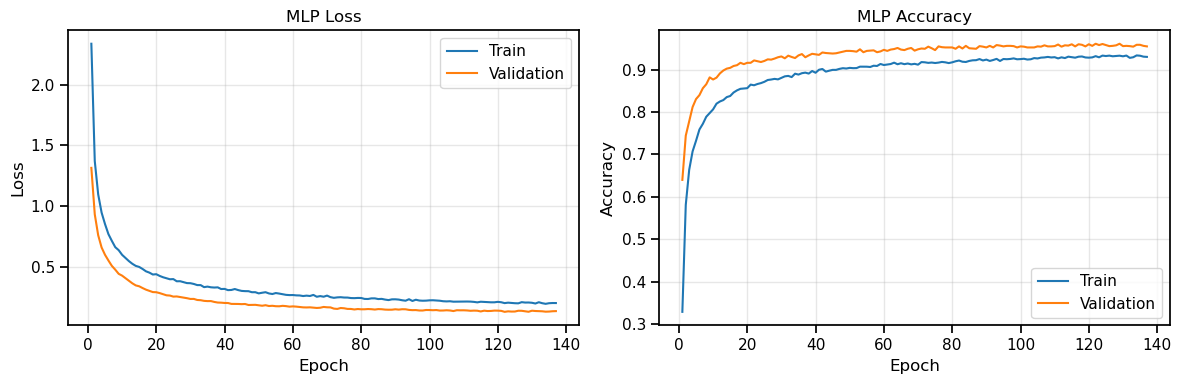

In [3]:
with open(models_dir() / 'mlp_history.json') as fh:
    history = json.load(fh)
fig = plot_training_curves(history, save_path=figures_dir() / 'mlp_training_curves.png')
plt.show()

## 2. SVM grid-search heatmap

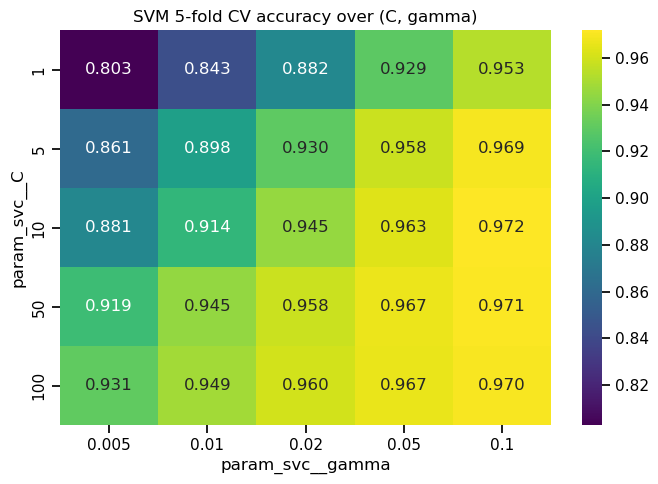

In [4]:
cv_df = pd.read_csv(outputs_dir() / 'svm_grid_search.csv')
pivot = cv_df.pivot_table(index='param_svc__C', columns='param_svc__gamma', values='mean_test_score')
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(pivot, annot=True, fmt='.3f', cmap='viridis', ax=ax)
ax.set_title('SVM 5-fold CV accuracy over (C, gamma)')
fig.tight_layout()
fig.savefig(figures_dir() / 'svm_grid_heatmap.png', dpi=200)
plt.show()

## 3. Confusion matrices (side-by-side)

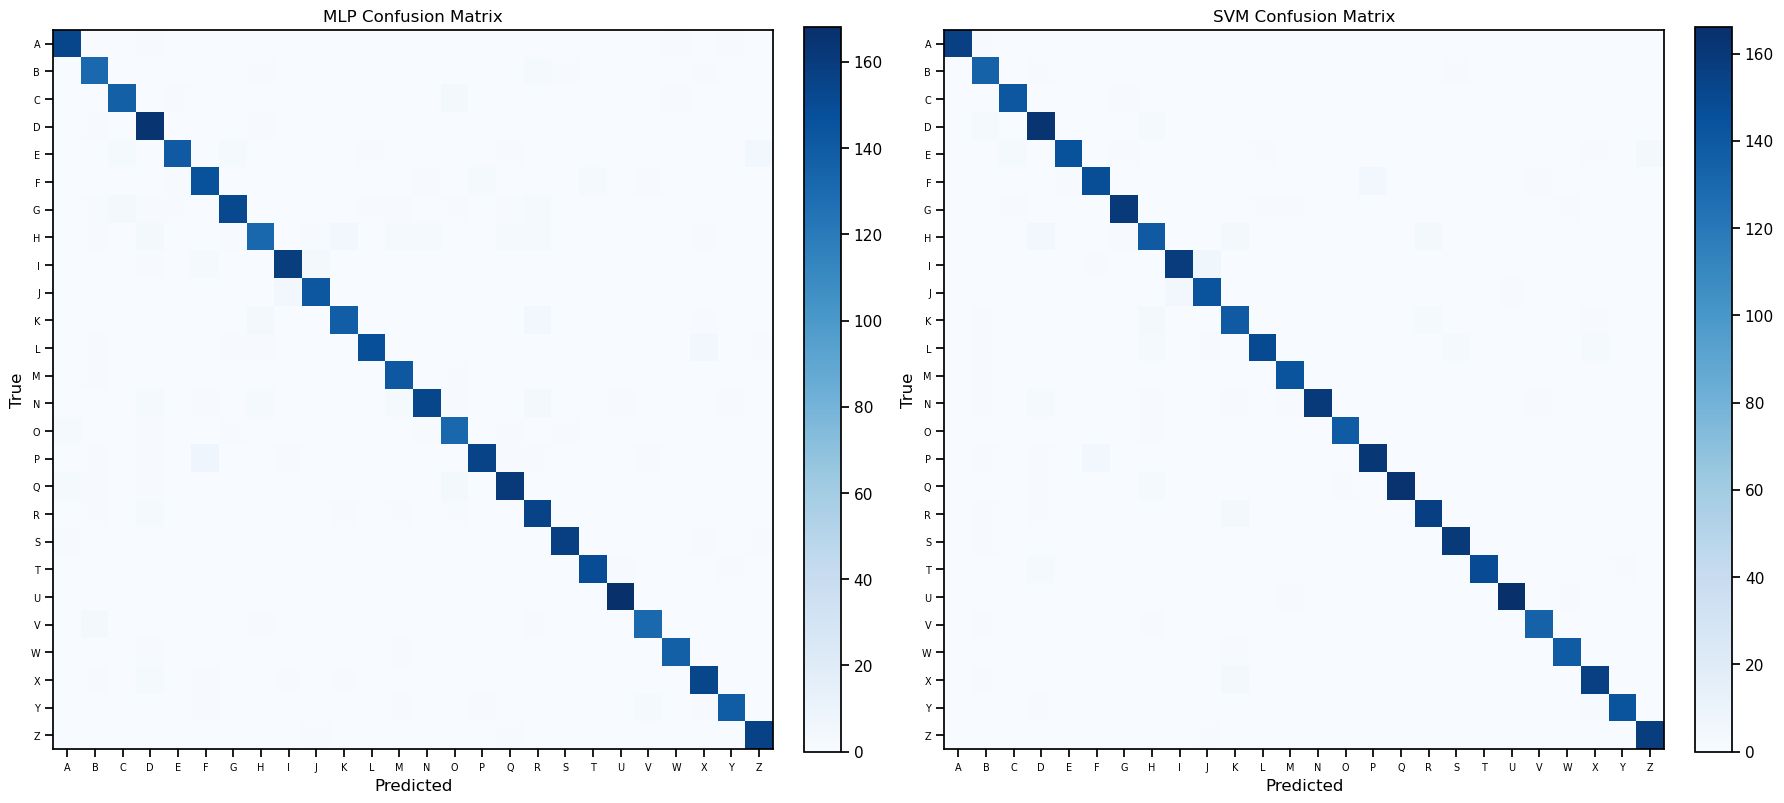

In [5]:
cm_mlp = confusion_matrix(data.y_test, mlp_pred, labels=range(26))
cm_svm = confusion_matrix(data.y_test, svm_pred, labels=range(26))

fig, axes = plt.subplots(1, 2, figsize=(18, 8))
for ax, cm, name in zip(axes, (cm_mlp, cm_svm), ('MLP', 'SVM')):
    im = ax.imshow(cm, cmap='Blues')
    ax.set_title(f'{name} Confusion Matrix')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
    ax.set_xticks(range(26)); ax.set_yticks(range(26))
    ax.set_xticklabels(LETTER_CLASSES, fontsize=7)
    ax.set_yticklabels(LETTER_CLASSES, fontsize=7)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
fig.tight_layout()
fig.savefig(figures_dir() / 'confusion_matrices_side_by_side.png', dpi=200)
plt.show()

## 4. Per-class F1

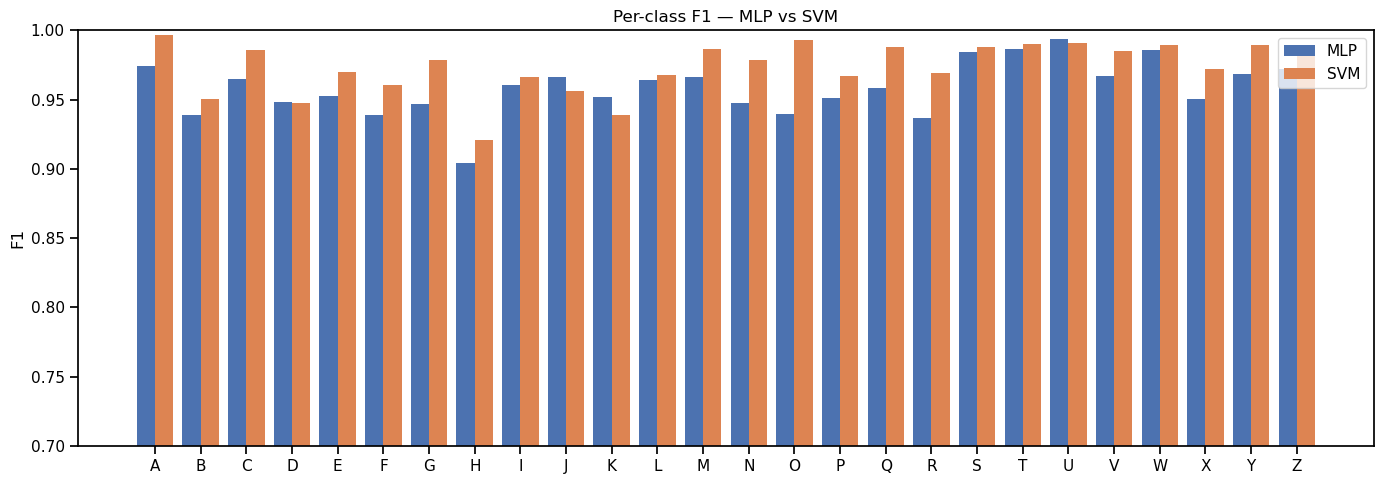

In [6]:
mlp_f1 = f1_score(data.y_test, mlp_pred, average=None, labels=range(26), zero_division=0)
svm_f1 = f1_score(data.y_test, svm_pred, average=None, labels=range(26), zero_division=0)

x = np.arange(26)
width = 0.4
fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(x - width/2, mlp_f1, width, label='MLP', color='#4c72b0')
ax.bar(x + width/2, svm_f1, width, label='SVM', color='#dd8452')
ax.set_xticks(x); ax.set_xticklabels(LETTER_CLASSES)
ax.set_ylabel('F1')
ax.set_title('Per-class F1 — MLP vs SVM')
ax.set_ylim(0.7, 1.0)
ax.legend()
fig.tight_layout()
fig.savefig(figures_dir() / 'per_class_f1.png', dpi=200)
plt.show()

## 5. Top-10 most-confused letter pairs (union across models)

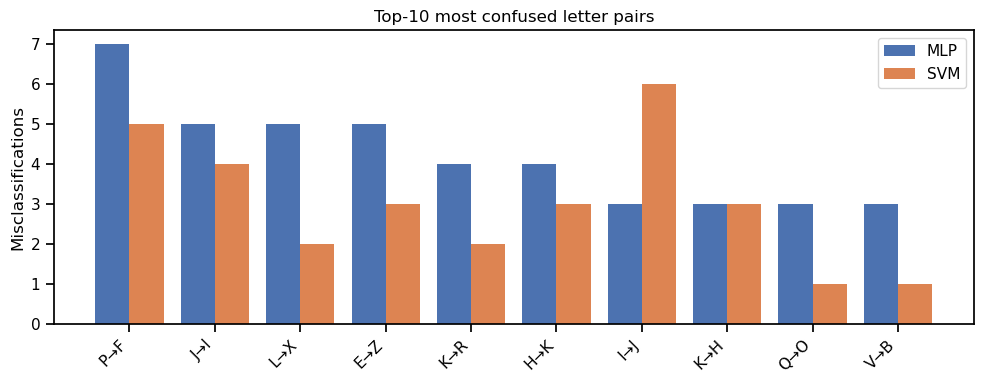

In [7]:
def top_confusions(cm, k=10):
    cm = cm.copy()
    np.fill_diagonal(cm, 0)
    idx = np.dstack(np.unravel_index(np.argsort(cm.ravel())[::-1], cm.shape))[0][:k]
    return [(LETTER_CLASSES[i], LETTER_CLASSES[j], int(cm[i, j])) for i, j in idx]

mlp_top = top_confusions(cm_mlp, 10)
svm_top = top_confusions(cm_svm, 10)

pairs = []
for row in mlp_top + svm_top:
    pair = f'{row[0]}→{row[1]}'
    pairs.append(pair)
# Keep the union of pairs that appear in either top-10, up to 10.
pairs = list(dict.fromkeys(pairs))[:10]

def count_for(cm, label):
    a, b = label.split('→')
    return int(cm[LETTER_CLASSES.index(a), LETTER_CLASSES.index(b)])

mlp_vals = [count_for(cm_mlp, p) for p in pairs]
svm_vals = [count_for(cm_svm, p) for p in pairs]

x = np.arange(len(pairs))
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(x - 0.2, mlp_vals, 0.4, label='MLP', color='#4c72b0')
ax.bar(x + 0.2, svm_vals, 0.4, label='SVM', color='#dd8452')
ax.set_xticks(x); ax.set_xticklabels(pairs, rotation=45, ha='right')
ax.set_ylabel('Misclassifications')
ax.set_title('Top-10 most confused letter pairs')
ax.legend()
fig.tight_layout()
fig.savefig(figures_dir() / 'top_confused_pairs.png', dpi=200)
plt.show()